In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
# Load the dataset
df = pd.read_csv('../datasets/churn-bigml-80.csv')

# Separate features and target
X_raw = df.drop(columns=['Churn'])
y = df['Churn'].astype(int) # Convert True/False to 1/0

# Convert categorical variables to numeric using One-Hot Encoding
# pd.get_dummies automatically detects object/text columns and encodes them
X = pd.get_dummies(X_raw, drop_first=True)

print("Preprocessed Features (X) Preview:")
display(X.head())

Preprocessed Features (X) Preview:


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_Yes,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set: {X_test.shape[0]} samples, {X_test.shape[1]} features")

Training set: 2132 samples, 68 features
Testing set: 534 samples, 68 features


In [4]:
# Define the parameter grid
param_dist = {
    # Number of trees in the forest
    'n_estimators': [100, 200, 300, 400],
    # Maximum depth of the tree
    'max_depth': [10, 20, 30, None],
    # Minimum samples required to split an internal node
    'min_samples_split': [2, 5, 10],
    # Minimum samples required to be at a leaf node
    'min_samples_leaf': [1, 2, 4],
    # Method of selecting samples for training each tree
    'bootstrap': [True, False]
}

# Initialize the base model
rf = RandomForestClassifier(random_state=42)

# Set up the randomized search with 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20,          # Number of parameter settings that are sampled
    cv=3,               # 3-fold cross-validation
    verbose=2,          # Output progress logs
    random_state=42, 
    n_jobs=-1           # Use all available CPU cores
)

# Fit the randomized search to the training data
random_search.fit(X_train, y_train)

# Retrieve the best model
best_rf = random_search.best_estimator_

print("\nBest Hyperparameters Found:")
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Hyperparameters Found:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 30, 'bootstrap': False}


In [5]:
# Predict on the testing set
y_pred = best_rf.predict(X_test)

print("--- Final Model Classification Report ---")
print(classification_report(y_test, y_pred))

# Perform 5-fold cross validation on the training data
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"5-Fold Cross-Validation Accuracy (Training): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

--- Final Model Classification Report ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       456
           1       1.00      0.64      0.78        78

    accuracy                           0.95       534
   macro avg       0.97      0.82      0.88       534
weighted avg       0.95      0.95      0.94       534

Test Set Accuracy: 0.9476
5-Fold Cross-Validation Accuracy (Training): 0.9395 (+/- 0.0035)


C:\Users\pijus\AppData\Local\Temp\ipykernel_26776\864985816.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


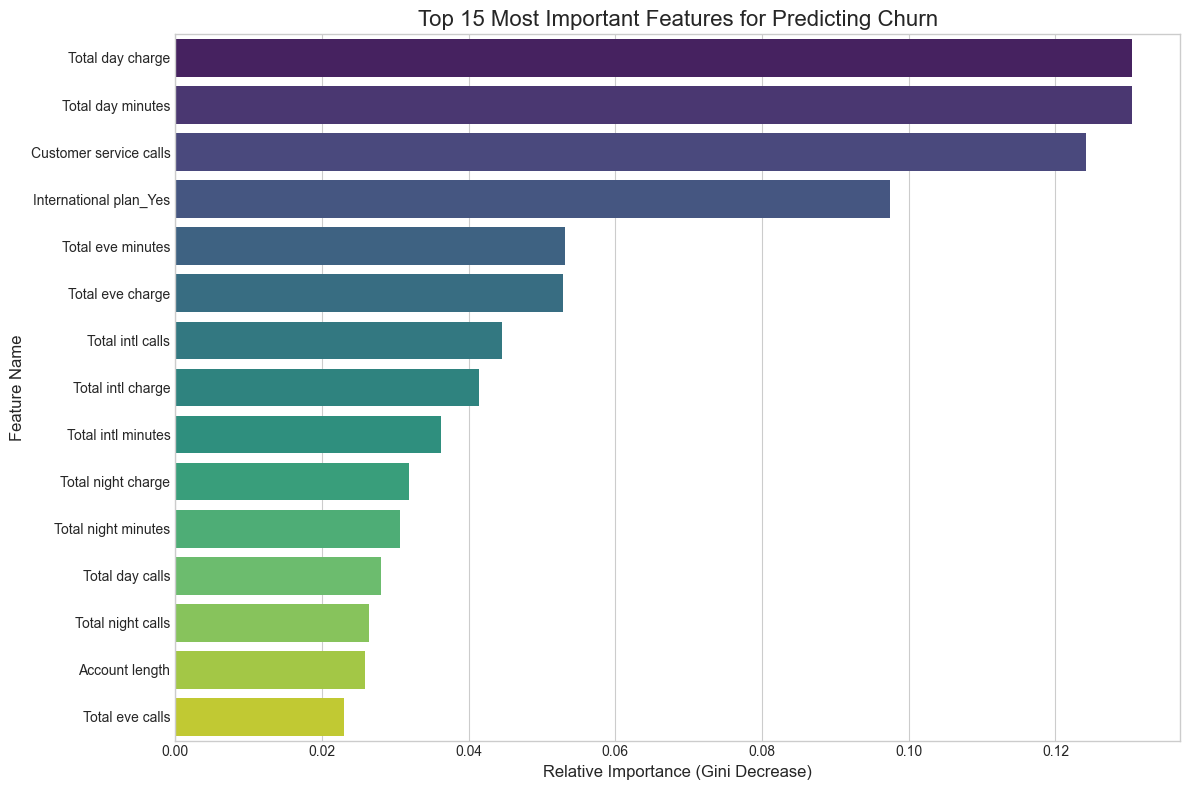

In [6]:
# Extract feature importances from the best model
importances = best_rf.feature_importances_

# Create a DataFrame to hold feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order and grab the top 15
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot the Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis'
)

plt.title('Top 15 Most Important Features for Predicting Churn', fontsize=16)
plt.xlabel('Relative Importance (Gini Decrease)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()